# Search Intelligence for Content Review: Combining CTR Opportunity Scoring with Decision Tree Signals

## Abstract

Search-intelligence teams need practical ways to identify content pages that deserve review without treating observed performance patterns as causal explanations of search rankings. This study asks which content-performance signals can help prioritize pages for search visibility and click-through opportunities using an anonymized FlyRank ML Internship dataset. I compare a transparent CTR-based baseline with a Decision Tree classifier trained using a client-grouped 80/20 split and a set of search, engagement, freshness, and content features. The Decision Tree achieved 69.79% accuracy on 6,163 held-out pages from seven unseen clients, but its macro F1 score was 0.49 and it failed to correctly classify the `excellent` impression tier. The results support a baseline-first, model-assisted, human-reviewed workflow in which CTR opportunity scoring identifies concrete review candidates while model signals provide additional directional context.


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SohailAkhtarChanna/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

### Research Question

Which content-performance signals can help identify pages that are worth reviewing for search visibility and click-through opportunities?

### Decision Supported

This work supports a content-review decision: which pages should be prioritized for further investigation rather than automatically changed. The goal is to provide a transparent, repeatable decision-support process using observed search and engagement signals.


In [20]:
# SECTION 1: Define the research question

research_question = (
    "Which content-performance signals can help identify pages "
    "that are worth reviewing for search visibility and click-through opportunities?"
)

decision_supported = (
    "Prioritize pages for content and CTR review using observed "
    "search and engagement signals."
)

print("Research question:")
print(research_question)

print("\nDecision supported:")
print(decision_supported)

Research question:
Which content-performance signals can help identify pages that are worth reviewing for search visibility and click-through opportunities?

Decision supported:
Prioritize pages for content and CTR review using observed search and engagement signals.


## Data

The analysis uses the anonymized FlyRank ML Internship development dataset, containing **30,000 content records and 44 columns**. The dataset includes search, content, engagement, freshness, and performance fields used to study content-review opportunities.

The analysis uses the following main feature groups:

* **Search signals:** search volume, competition, and CPC.
* **Content signals:** word count and character count.
* **Freshness signals:** content age and days since last update.
* **Search-performance signals:** average position and CTR.
* **Engagement signals:** engagement rate, scroll rate, and AI traffic percentage.
* **Target:** `impression_tier`, representing the observed impression-performance tier.

For model evaluation, the data was divided using a **client-grouped 80/20 split**. The training set contains 23,837 records from 25 clients, while the held-out test set contains 6,163 records from seven unseen clients. There was no client overlap between the two sets.

Missing feature values were handled using **training-set medians only**. The same training medians were then applied to the test set to avoid using information from the held-out data during preprocessing.

The Decision Tree uses the observed development dataset available for this capstone. The Week-4 CTR baseline uses the documented February performance window and applies its CTR opportunity rule to the held-out test records for the comparison.

No client names, domains, private search queries, credentials, or raw client exports are included in the public-facing analysis. Results are presented at an anonymized and aggregate level.

Because the target represents observed impression performance, the analysis measures patterns in the available dataset rather than proving changes in Google's ranking algorithm or establishing causal relationships between individual features and search outcomes.


In [21]:
import os

print("Files/folders in /content:")
print(os.listdir("/content"))

Files/folders in /content:
['.config', 'flyrank-ml-internship', 'sample_data']


In [22]:
!git clone https://github.com/SohailAkhtarChanna/flyrank-ml-internship.git

fatal: destination path 'flyrank-ml-internship' already exists and is not an empty directory.


In [23]:
import os

DATA_PATH = "/content/flyrank-ml-internship/data/raw/content_refresh_anonymized.csv"

print("Dataset exists:", os.path.exists(DATA_PATH))
print("Dataset path:", DATA_PATH)

Dataset exists: True
Dataset path: /content/flyrank-ml-internship/data/raw/content_refresh_anonymized.csv


In [24]:
# Load the FlyRank dataset

import pandas as pd

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("Columns:", len(df.columns))

Dataset loaded successfully!
Shape: (30000, 44)
Columns: 44


In [25]:
# Define features and target

feature_columns = [
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "content_age_days",
    "days_since_last_update",
    "avg_position",
    "ctr",
    "engagement_rate",
    "scroll_rate",
    "ai_traffic_pct"
]

target = "impression_tier"

print("Number of features:", len(feature_columns))
print("Features:", feature_columns)
print("Target:", target)

Number of features: 12
Features: ['search_volume', 'competition', 'cpc', 'word_count', 'char_count', 'content_age_days', 'days_since_last_update', 'avg_position', 'ctr', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct']
Target: impression_tier


In [26]:
# Client-grouped train/test split

from sklearn.model_selection import GroupShuffleSplit

print("Client column:", "client_id")
print("Number of unique clients:", df["client_id"].nunique())
print("Number of rows:", len(df))

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(df, groups=df["client_id"])
)

train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))
print("Training clients:", train_df["client_id"].nunique())
print("Testing clients:", test_df["client_id"].nunique())

overlap = set(train_df["client_id"]) & set(test_df["client_id"])
print("Client overlap:", len(overlap))

Client column: client_id
Number of unique clients: 32
Number of rows: 30000
Training rows: 23837
Testing rows: 6163
Training clients: 25
Testing clients: 7
Client overlap: 0


In [27]:
# Prepare training and testing data

X_train = train_df[feature_columns].copy()
X_test = test_df[feature_columns].copy()

y_train = train_df[target]
y_test = test_df[target]

# Fill missing values using training-set medians only
train_medians = X_train.median()

X_train = X_train.fillna(train_medians)
X_test = X_test.fillna(train_medians)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nRemaining missing values in X_train:", X_train.isna().sum().sum())
print("Remaining missing values in X_test:", X_test.isna().sum().sum())

X_train shape: (23837, 12)
X_test shape: (6163, 12)
y_train shape: (23837,)
y_test shape: (6163,)

Remaining missing values in X_train: 0
Remaining missing values in X_test: 0


## Methodology

### Research Design

The analysis treats the task as **decision support for content review**, rather than as a system for predicting or explaining Google's ranking algorithm. The objective is to identify useful observed signals and compare two practical prioritization approaches.

### Features and Target

The Decision Tree uses 12 features covering search demand, competition, content size, freshness, search performance, and engagement:

`search_volume`, `competition`, `cpc`, `word_count`, `char_count`, `content_age_days`, `days_since_last_update`, `avg_position`, `ctr`, `engagement_rate`, `scroll_rate`, and `ai_traffic_pct`.

The target variable is `impression_tier`, with four observed classes: `low`, `moderate`, `good`, and `excellent`.

### Missing-Value Handling

Missing feature values are imputed using the **median calculated from the training set only**. Those same medians are applied to the held-out test set. This prevents information from the test set from influencing preprocessing.

### Validation Design

To reduce client-specific leakage, I use a **client-grouped 80/20 train-test split**. The training set contains 23,837 records from 25 clients, and the test set contains 6,163 records from seven unseen clients. The two sets have zero client overlap.

This grouped split is more conservative than a random row-level split because content from the same client cannot appear in both training and testing data.

### Model

The selected model is a **Decision Tree Classifier** with `max_depth=5` and `random_state=42`. The tree was chosen because its decision structure is relatively interpretable and suitable for a decision-support workflow.

### Baseline

The comparison baseline is the Week-4 CTR opportunity score. It prioritizes pages with meaningful search exposure and CTR below the average CTR for their search-position bucket.

The baseline uses four position buckets: `1-3`, `4-10`, `11-20`, and `21+`. It requires at least 100 impressions and a positive CTR gap. Its score is:

`log1p(impressions) × CTR gap`

The baseline is a transparent review-prioritization rule, not a classifier.

### Leakage Checks

The model evaluation uses a held-out client-grouped test set. Test-set medians are not used for imputation, and client IDs are not used as predictive features.

The baseline comparison is also calculated on the same held-out test records. The baseline uses observed impressions and CTR to construct its review score, while the Decision Tree estimates observed impression tiers from the selected feature set.

The February performance window used by the original Week-4 baseline is kept separate from future outcome information. No future-window outcome fields are intentionally introduced into the baseline scoring rule.

### Comparison Approach

Because the baseline and Decision Tree solve different prioritization problems, their raw outputs are not treated as directly comparable accuracy metrics. Instead, I compare their **Top-20 queues** on the same held-out test set and examine the observed impression-tier composition of those queues.

This comparison is descriptive and decision-oriented. It shows whether the two approaches prioritize similar or different pages and provides context for deciding how they could be used together.


In [28]:
# Train the Decision Tree model

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Decision Tree trained successfully!")
print("Test accuracy:", round(accuracy, 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

Decision Tree trained successfully!
Test accuracy: 0.6979

Classification Report:
              precision    recall  f1-score   support

   excellent       0.00      0.00      0.00       166
        good       0.67      0.41      0.51      1180
         low       0.80      0.90      0.84      2818
    moderate       0.57      0.65      0.60      1999

    accuracy                           0.70      6163
   macro avg       0.51      0.49      0.49      6163
weighted avg       0.68      0.70      0.68      6163



In [29]:
# Feature importance

import pandas as pd

feature_importance = pd.DataFrame({
    "feature": feature_columns,
    "importance": model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

print(feature_importance.to_string(index=False))

               feature  importance
                   ctr    0.679804
       engagement_rate    0.163583
days_since_last_update    0.077895
          avg_position    0.037702
           scroll_rate    0.015309
      content_age_days    0.015149
            word_count    0.009093
            char_count    0.001464
                   cpc    0.000000
           competition    0.000000
         search_volume    0.000000
        ai_traffic_pct    0.000000


### Results

The Decision Tree achieved **69.79% accuracy** on the held-out test set containing 6,163 content items from seven unseen clients. Performance was strongest for the `low` impression tier, with an F1 score of 0.84 and recall of 0.90. Performance was weaker for the `good` and `moderate` tiers, while the model did not correctly classify any items in the `excellent` tier.

The fitted tree's feature importance was concentrated in a small number of observed signals. CTR accounted for approximately 68.0% of the model's feature importance, followed by engagement rate at approximately 16.4%, days since last update at 7.8%, and average position at 3.8%. Search volume, competition, CPC, and AI traffic percentage had zero importance in this particular fitted tree.

These results indicate that the selected performance signals contain useful information for separating some impression-performance tiers, particularly the lower tier. However, the model does not reliably distinguish the highest-performing classes. The feature-importance values describe how the fitted Decision Tree used the available features; they should not be interpreted as causal effects or as evidence of Google's ranking factors.


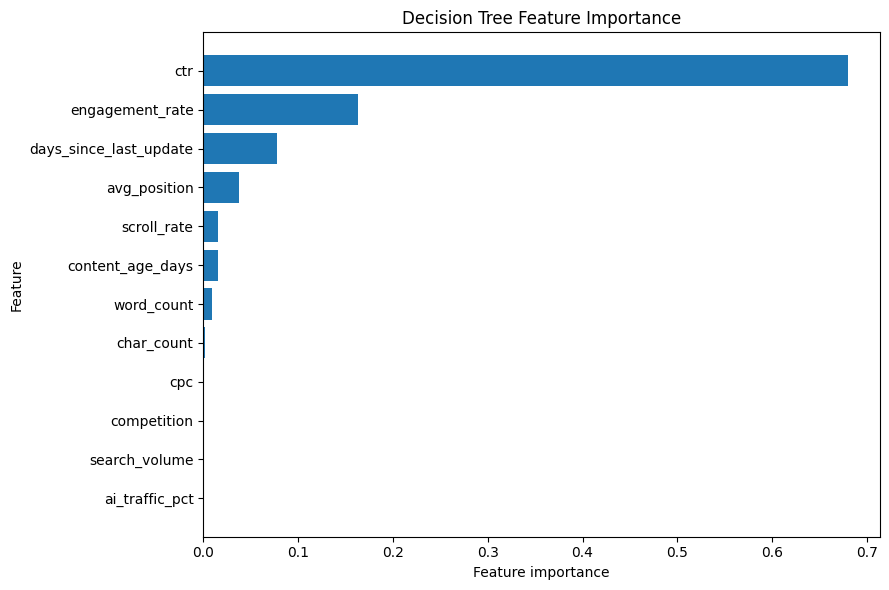

In [30]:
import matplotlib.pyplot as plt

# Plot feature importance
plot_df = feature_importance.sort_values("importance", ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(plot_df["feature"], plot_df["importance"])
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("Decision Tree Feature Importance")
plt.tight_layout()
plt.show()

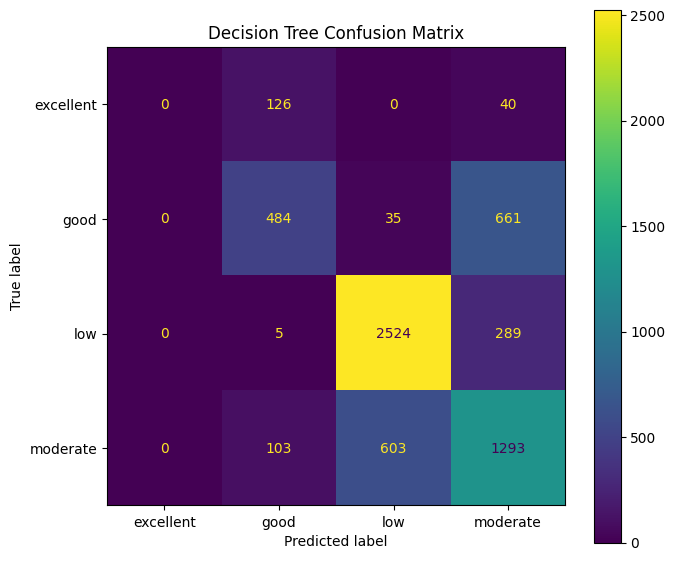

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["excellent", "good", "low", "moderate"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["excellent", "good", "low", "moderate"]
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, values_format="d")
ax.set_title("Decision Tree Confusion Matrix")
plt.tight_layout()
plt.show()

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [32]:
# Create the Week-4 style CTR opportunity baseline on the capstone test set

baseline_df = test_df.copy()

# Position buckets
baseline_df["position_bucket"] = pd.cut(
    baseline_df["avg_position"],
    bins=[0, 3, 10, 20, float("inf")],
    labels=["1-3", "4-10", "11-20", "21+"],
    include_lowest=True
)

# Calculate average CTR within each position bucket
bucket_avg_ctr = (
    baseline_df
    .groupby("position_bucket", observed=False)["ctr"]
    .mean()
    .rename("bucket_avg_ctr")
)

baseline_df = baseline_df.join(bucket_avg_ctr, on="position_bucket")

# CTR gap: positive means below the average for its position bucket
baseline_df["ctr_gap"] = (
    baseline_df["bucket_avg_ctr"] - baseline_df["ctr"]
)

# Baseline opportunity score
baseline_df["baseline_score"] = (
    __import__("numpy").log1p(baseline_df["impressions_90d"])
    * baseline_df["ctr_gap"]
)

# Keep pages with positive CTR gap and meaningful exposure
baseline_ranked = baseline_df[
    (baseline_df["impressions_90d"] >= 100) &
    (baseline_df["ctr_gap"] > 0)
].copy()

baseline_ranked = baseline_ranked.sort_values(
    ["baseline_score", "impressions_90d"],
    ascending=[False, False]
)

baseline_ranked["baseline_rank"] = range(1, len(baseline_ranked) + 1)

print("Test-set rows:", len(test_df))
print("Baseline review candidates:", len(baseline_ranked))

print("\nTop 10 baseline opportunities:")
print(
    baseline_ranked[
        [
            "content_id",
            "impressions_90d",
            "ctr",
            "avg_position",
            "ctr_gap",
            "baseline_score",
            "baseline_rank"
        ]
    ].head(10).to_string(index=False)
)

Test-set rows: 6163
Baseline review candidates: 2668

Top 10 baseline opportunities:
          content_id  impressions_90d  ctr  avg_position  ctr_gap  baseline_score  baseline_rank
content_453722754fea           140079 0.01           7.6 0.376475        4.461219              1
content_c84a0ab98e90           223271 0.03           7.8 0.356475        4.390400              2
content_39881853ef0c           112434 0.01           7.2 0.376475        4.378455              3
content_0919dd345d80           119217 0.02           7.0 0.366475        4.283622              4
content_d274ac4158ef            65138 0.01           6.8 0.376475        4.172956              5
content_e5f459e737b7            56363 0.01           5.9 0.376475        4.118483              6
content_65d9331f55fb            65686 0.02           7.8 0.366475        4.065183              7
content_ca17a024f90c            38815 0.01           9.1 0.376475        3.978058              8
content_f6ae0f36d70d            44860 0.02

In [33]:
# Create a ranking from the Decision Tree predictions

model_ranked = test_df.copy()

# Get predicted class probabilities
probabilities = model.predict_proba(X_test)

# Map each impression tier to an ordinal value
tier_values = {
    "low": 1,
    "moderate": 2,
    "good": 3,
    "excellent": 4
}

# Calculate expected impression tier
model_ranked["model_score"] = sum(
    probabilities[:, i] * tier_values[cls]
    for i, cls in enumerate(model.classes_)
)

# Higher score = higher predicted impression tier
model_ranked = model_ranked.sort_values(
    ["model_score", "impressions_90d"],
    ascending=[False, False]
)

model_ranked["model_rank"] = range(1, len(model_ranked) + 1)

print("Model-ranked test rows:", len(model_ranked))

print("\nTop 10 model-ranked pages:")
print(
    model_ranked[
        [
            "content_id",
            "impressions_90d",
            "ctr",
            "avg_position",
            "impression_tier",
            "model_score",
            "model_rank"
        ]
    ].head(10).to_string(index=False)
)

Model-ranked test rows: 6163

Top 10 model-ranked pages:
          content_id  impressions_90d  ctr  avg_position impression_tier  model_score  model_rank
content_db5989a78dd3           345111 0.21           5.4       excellent     3.446729           1
content_73c54f78c06a           213963 0.10           4.7       excellent     3.446729           2
content_82572b951646            80655 0.25           4.6       excellent     3.446729           3
content_a2724f91a165            71442 0.21           4.6       excellent     3.446729           4
content_10ec67c6a68d            69846 0.25           6.6       excellent     3.446729           5
content_e0b08ad65f5b            69460 0.12           6.2       excellent     3.446729           6
content_bdd7c88a58ed            64718 0.84           3.1       excellent     3.446729           7
content_ceaa28bba4ca            43287 0.06           3.9       excellent     3.446729           8
content_8350242b2df4            42441 0.17           5.5     

In [34]:
# Compare the top 20 pages from the baseline and model rankings

TOP_K = 20

baseline_top20 = set(
    baseline_ranked.head(TOP_K)["content_id"]
)

model_top20 = set(
    model_ranked.head(TOP_K)["content_id"]
)

overlap = baseline_top20 & model_top20

print("Baseline Top-20:", len(baseline_top20))
print("Model Top-20:", len(model_top20))
print("Top-20 overlap:", len(overlap))
print("Overlap percentage:", round(len(overlap) / TOP_K * 100, 1), "%")

print("\nBaseline Top-20 actual impression tiers:")
print(
    baseline_ranked.head(TOP_K)["impression_tier"]
    .value_counts()
)

print("\nModel Top-20 actual impression tiers:")
print(
    model_ranked.head(TOP_K)["impression_tier"]
    .value_counts()
)

Baseline Top-20: 20
Model Top-20: 20
Top-20 overlap: 0
Overlap percentage: 0.0 %

Baseline Top-20 actual impression tiers:
impression_tier
excellent    14
good          6
Name: count, dtype: int64

Model Top-20 actual impression tiers:
impression_tier
excellent    15
good          5
Name: count, dtype: int64


### Baseline Comparison

The Week-4 CTR baseline and the Decision Tree produce substantially different prioritization queues on the same held-out test set. There was **0% overlap** between their Top-20 content items.

Despite selecting different pages, both approaches concentrated their Top-20 queues on higher observed impression tiers. The baseline selected 14 `excellent` and 6 `good` items, while the Decision Tree selected 15 `excellent` and 5 `good` items.

This result should not be interpreted as evidence that one approach is universally better. The two methods use different signals and objectives: the baseline explicitly prioritizes positive CTR gaps combined with search exposure, while the Decision Tree estimates impression-performance tiers from a broader set of content and engagement features.

The practical implication is that the two approaches can be viewed as complementary decision-support tools. The CTR baseline highlights pages with potentially weak click-through performance relative to their position, while the model provides an alternative prioritization based on the observed feature patterns learned from the training data.


                 Baseline  Decision Tree
impression_tier                         
excellent              14             15
good                    6              5
moderate                0              0
low                     0              0


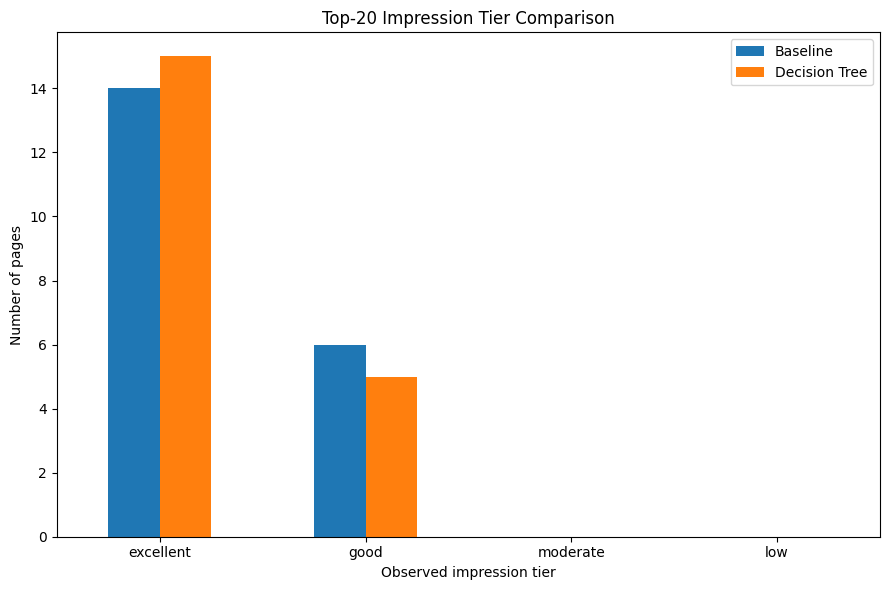

In [35]:
# Compare impression tiers in the Top-20 queues

tier_order = ["excellent", "good", "moderate", "low"]

baseline_counts = (
    baseline_ranked.head(20)["impression_tier"]
    .value_counts()
    .reindex(tier_order, fill_value=0)
)

model_counts = (
    model_ranked.head(20)["impression_tier"]
    .value_counts()
    .reindex(tier_order, fill_value=0)
)

comparison_chart = pd.DataFrame({
    "Baseline": baseline_counts,
    "Decision Tree": model_counts
})

print(comparison_chart)

comparison_chart.plot(
    kind="bar",
    figsize=(9, 6)
)

plt.title("Top-20 Impression Tier Comparison")
plt.xlabel("Observed impression tier")
plt.ylabel("Number of pages")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Limitations

The results should be interpreted as **directional decision support**, not as proof of causal effects or Google's ranking factors. The Decision Tree achieved 69.79% accuracy, but its macro F1 score was 0.49 and it did not correctly classify any items in the `excellent` impression tier. This indicates that overall accuracy is partly driven by stronger performance on the lower-frequency classes and does not mean that all impression tiers are predicted reliably.

The dataset is also imbalanced across impression tiers, and the fitted tree relied heavily on CTR and engagement rate. Feature importance describes how the model used the available features in this specific training run; it does not establish that these variables cause better or worse search performance.

The Week-4 CTR baseline and the Decision Tree also produce different prioritization queues. Their Top-20 overlap was 0%, so the comparison is best understood as showing **different decision-support perspectives**, rather than proving that one method is better. The baseline focuses on high-exposure pages with below-bucket-average CTR, while the model learns patterns associated with observed impression tiers.

Finally, the Decision Tree produced tied model scores for several top-ranked items because pages reaching the same terminal tree leaf receive the same predicted class probabilities. For practical deployment, the ranking should therefore be combined with transparent business rules and human review rather than used as an automatic content-action system.


### Ranked Recommendations

The analysis supports a practical review workflow that combines the transparent CTR baseline with the Decision Tree as complementary evidence.

**Priority 1 — Review high-exposure, low-CTR pages**

Start with pages identified by the Week-4 CTR baseline: pages with at least 100 impressions and CTR below the average for their search-position bucket. These pages have measurable search exposure but appear to capture fewer clicks than comparable pages at similar positions. Review their titles, descriptions, search intent alignment, SERP presentation, and content relevance before making changes.

**Priority 2 — Validate pages with strong model signals**

Use the Decision Tree as a secondary signal when prioritizing pages for analysis. CTR, engagement rate, days since last update, and average position were the most influential features in the fitted model. These signals can help identify performance patterns that deserve investigation, but they should not be treated as causal ranking factors.

**Priority 3 — Investigate higher-tier and ambiguous cases manually**

The model struggled to distinguish the `excellent` tier and frequently confused neighboring `good`, `moderate`, and `low` classes. Pages falling into these ambiguous areas should therefore be reviewed by a human rather than automatically assigned an action.

**Priority 4 — Combine model evidence with contextual checks**

Before recommending a content change, check factors not represented in the model, including search intent, SERP features, brand effects, content quality, and measurement issues. The final action should be based on multiple pieces of evidence rather than a single model score.

Overall, the recommended workflow is **baseline-first, model-assisted, human-reviewed**: use the transparent CTR rule to identify concrete review opportunities, use the model to provide additional performance context, and require human validation before taking action.


### Reproducibility

The analysis is implemented in the FlyRank ML Internship repository and can be reproduced from the capstone notebook.

The main analysis notebook is:

`work/notebooks/capstone.ipynb`

The workflow loads the anonymized development dataset, applies the documented feature selection and train-only median imputation, creates a client-grouped 80/20 train-test split, trains the Decision Tree classifier, evaluates its predictions, constructs the Week-4-style CTR baseline on the same held-out test set, and compares the resulting prioritization queues.

The analysis is designed to run from top to bottom so that the data preparation, model training, evaluation, visualizations, baseline comparison, and recommendations can be reproduced in sequence.

The repository also contains the earlier internship notebooks that provide the development context for the baseline and model.

All results in this paper should be understood within the scope of the anonymized FlyRank ML Internship dataset and the methodology documented in this notebook.


### Acknowledgments & Data Credit

Built on the FlyRank ML Internship dataset. The analysis was completed as part of the FlyRank ML Internship and uses an anonymized development dataset for search-intelligence research and decision-support analysis.


### Artifacts

The deployed paper will present the following artifacts:

1. **Decision Tree Feature Importance** — shows which observed features contributed most to the fitted model.
2. **Confusion Matrix** — shows classification performance across the four observed impression tiers.
3. **Top-20 Impression Tier Comparison** — compares the observed impression-tier composition of the Top-20 pages selected by the CTR baseline and Decision Tree.
4. **Baseline vs Decision Tree Top-20 overlap** — reports the degree to which the two approaches prioritize the same pages.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.


## ML-12 — 5-Minute Demo Outline

**0:00–0:45 — Problem**
Explain that the goal is to identify content pages that are worth reviewing for search visibility and click-through opportunities using observed performance data.

**0:45–1:30 — Data and methodology**
Briefly describe the anonymized dataset, the 12 selected features, the `impression_tier` target, and the client-grouped 80/20 train-test split.

**1:30–2:30 — Model results**
Show the Decision Tree results: 69.79% accuracy, macro F1 of 0.49, and the feature-importance chart. Highlight that CTR was the strongest feature in this fitted tree.

**2:30–3:30 — Baseline comparison**
Show the CTR baseline and Decision Tree Top-20 comparison. Explain that the two approaches had 0% Top-20 overlap but selected similarly high observed impression tiers.

**3:30–4:30 — Recommendations and limitations**
Explain the baseline-first, model-assisted, human-reviewed workflow. Emphasize that the model is directional decision support and does not prove causal ranking factors.

**4:30–5:00 — Takeaway**
Conclude that transparent CTR opportunity scoring provides a practical review queue, while the Decision Tree adds complementary performance context. Future work should improve minority-class detection and validate the approach on additional data.


I completed a Search Intelligence capstone focused on identifying content pages worth reviewing for search visibility and CTR opportunities.

Using an anonymized FlyRank ML Internship dataset, I compared a transparent CTR-based review baseline with a Decision Tree classifier using a client-grouped evaluation setup.

The Decision Tree achieved 69.79% accuracy, while CTR, engagement rate, freshness, and average position were the strongest signals in the fitted model. The model and baseline produced different Top-20 review queues, showing that they can provide complementary perspectives rather than replacing one another.

The key takeaway: **baseline-first, model-assisted, human-reviewed** decision support can help turn search-performance data into practical content-review priorities—without overclaiming causality.

#MachineLearning #SearchIntelligence #DataScience #ContentStrategy #Python


## ML-12 — Employer-Facing Summary

I built a Search Intelligence decision-support workflow that combines a transparent CTR opportunity baseline with a client-grouped Decision Tree model to prioritize content for review. The model achieved 69.79% accuracy on held-out data from unseen clients, with CTR and engagement-related signals contributing most strongly to the fitted tree. The project demonstrates my ability to turn real-world search-performance data into reproducible analysis, interpretable ML results, practical recommendations, and an honest evaluation of model limitations.
